# Статистика в области кибербезопасности: анализ угроз и обнаружение аномалий

Датасет: **RT-IoT2022** из UCI.

Этот ноутбук сделан как компактная версия проекта для показа на защите: данные, ключевые расчеты, графики, гипотезы и регрессия.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / 'raw' / 'rt_iot2022.csv'
NORMAL_LABELS = {'Thing_Speak', 'MQTT_Publish', 'Wipro_bulb'}


## 1. Загрузка и подготовка данных

Разделяем трафик на `Normal` и `Attack`. Нормальными считаются `Thing_Speak`, `MQTT_Publish` и `Wipro_bulb`, остальные метки относятся к атакам.

In [2]:
df = pd.read_csv(DATA_PATH)
df['is_attack'] = (~df['Attack_type'].isin(NORMAL_LABELS)).astype(int)
df['traffic_class'] = df['is_attack'].map({0: 'Normal', 1: 'Attack'})

df.head()

,id,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type,is_attack,traffic_class
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,2.026391e+06,506597.757339,680406.147100,761.985779,29729182.96,32011597.87,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2282414.913,2282414.913,2282414.913,2282414.913,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish,0,Normal
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,1.876261e+06,469065.249000,741351.686200,247.001648,29855277.06,31883584.02,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2028306.961,2028306.961,2028306.961,2028306.961,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish,0,Normal
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,2.013770e+06,503442.466300,660344.360027,283.956528,29842149.02,32124053.00,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2281903.982,2281903.982,2281903.982,2281903.982,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish,0,Normal
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,288.963318,29913774.97,31961063.15,3995132.893,10482528.22,3933.906555,1551892.042,1.883784e+06,470946.013927,724569.317900,288.963318,29913774.97,31961063.15,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2047288.179,2047288.179,2047288.179,2047288.179,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish,0,Normal
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,387.907028,29814704.90,31902361.87,3987795.234,10447019.10,3005.02

In [3]:
overview = pd.DataFrame({
    'metric': [
        'observations',
        'original_columns_total',
        'missing_values_total',
        'attack_share',
        'normal_share',
    ],
    'value': [
        len(df),
        len(df.columns) - 2,
        int(df.isna().sum().sum()),
        df['is_attack'].mean(),
        1 - df['is_attack'].mean(),
    ]
})
overview

,metric,value
0,observations,123117.000000
1,original_columns_total,85.000000
2,missing_values_total,0.000000
3,attack_share,0.898414
4,normal_share,0.101586


## 2. Ключевые описательные статистики

Смотрим признаки, которые лучше всего объяснять устно на защите.

In [4]:
features = ['flow_duration', 'flow_pkts_per_sec', 'payload_bytes_per_second', 'fwd_init_window_size']
summary = df.groupby('traffic_class')[features].describe().round(2)
summary

flow_duration                                                  flow_pkts_per_sec                                                                          payload_bytes_per_second  \
                      count   mean     std  min   25%   50%    75%       max             count       mean        std  min        25%        50%         75%         max                    count   
traffic_class                                                                                                                                                                                      
Attack             110610.0   1.20   29.22  0.0  0.00  0.00   0.00   5341.39          110610.0  783116.17  741489.32  0.0  399457.52  493447.53  1048576.00  2097152.00                 110610.0   
Normal              12507.0  26.86  397.80  0.0  0.04  0.88  31.91  21728.34           12507.0      58.94     356.54  0.0       0.44      15.77       77.88    16677.15                  12507.0   

                                                                                                  fwd_init_window_size                                                            
                      mean          std  min          25%          50%          75%           max                count      mean       std  min   25%      50%      75%      max  
traffic_class                                                                                                                                                                     
Attack         45695073.65  45028812.78  0.0  19358326.15  29606851.76  62914560.00  1.258291e+08             110610.0   2181.59  11387.37  0.0  64.0     64.0     64.0  65495.0  
Normal             3656.20     27610.93  0.0         3.38       975.04      4764.16  1.817810e+06              12507.0  40939.95  30853.77  0.0   0.0  64240.0  64240.0  65535.0

## 3. Графики

Ниже те же графики, которые используются в проекте.

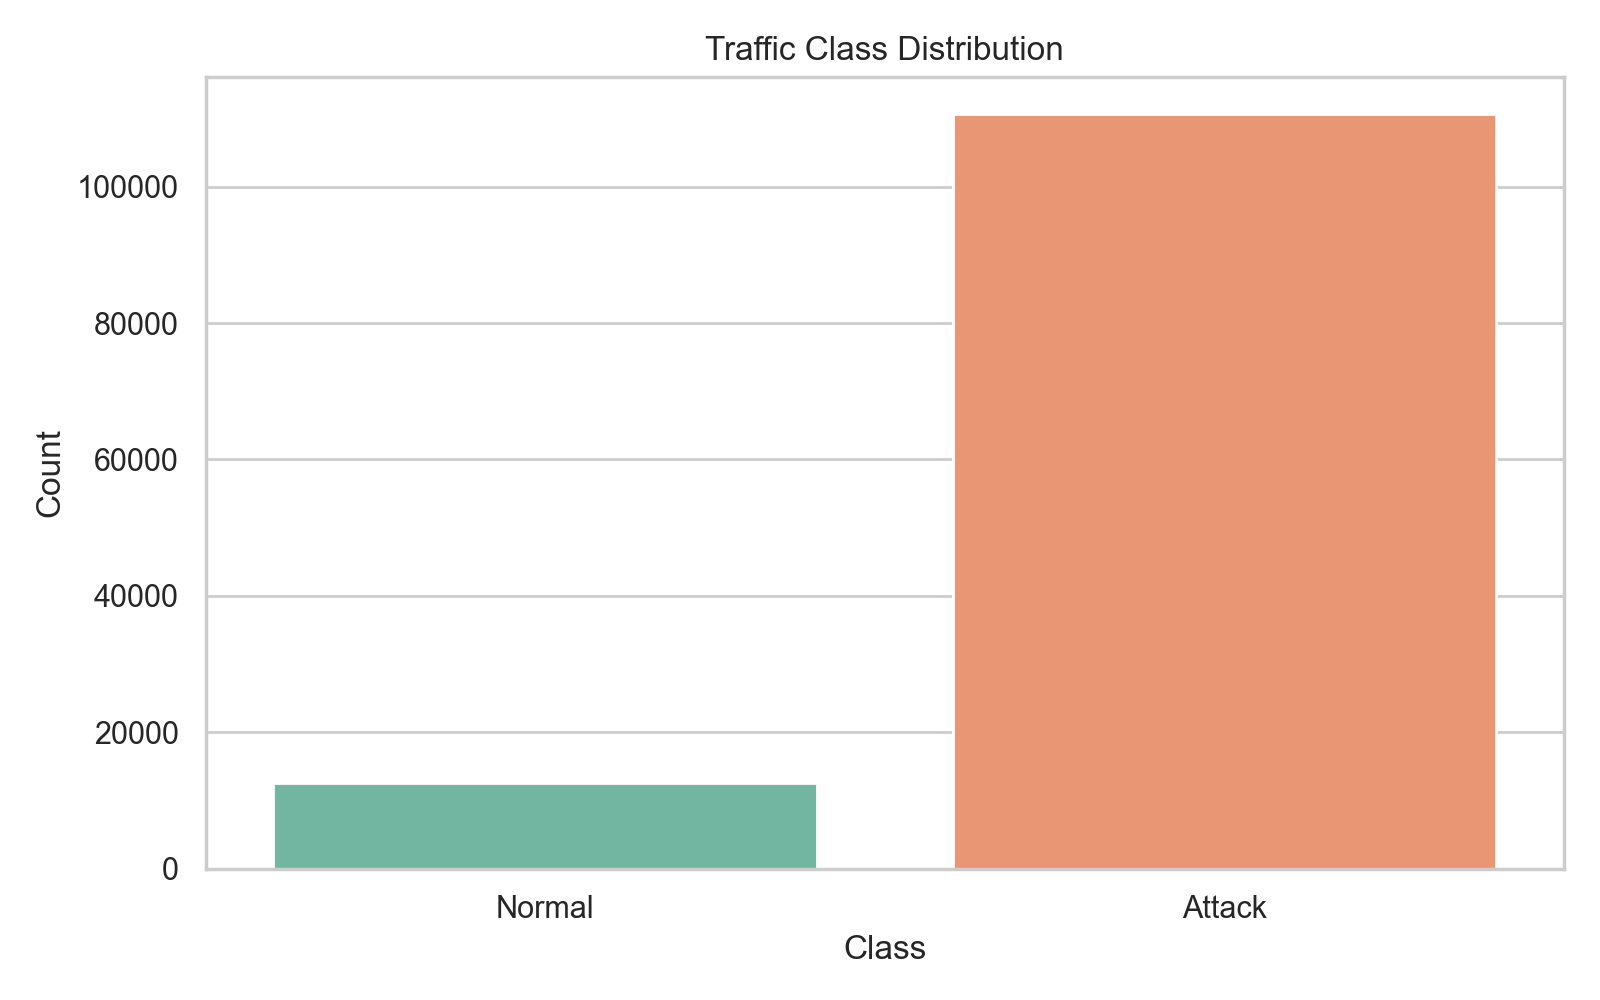

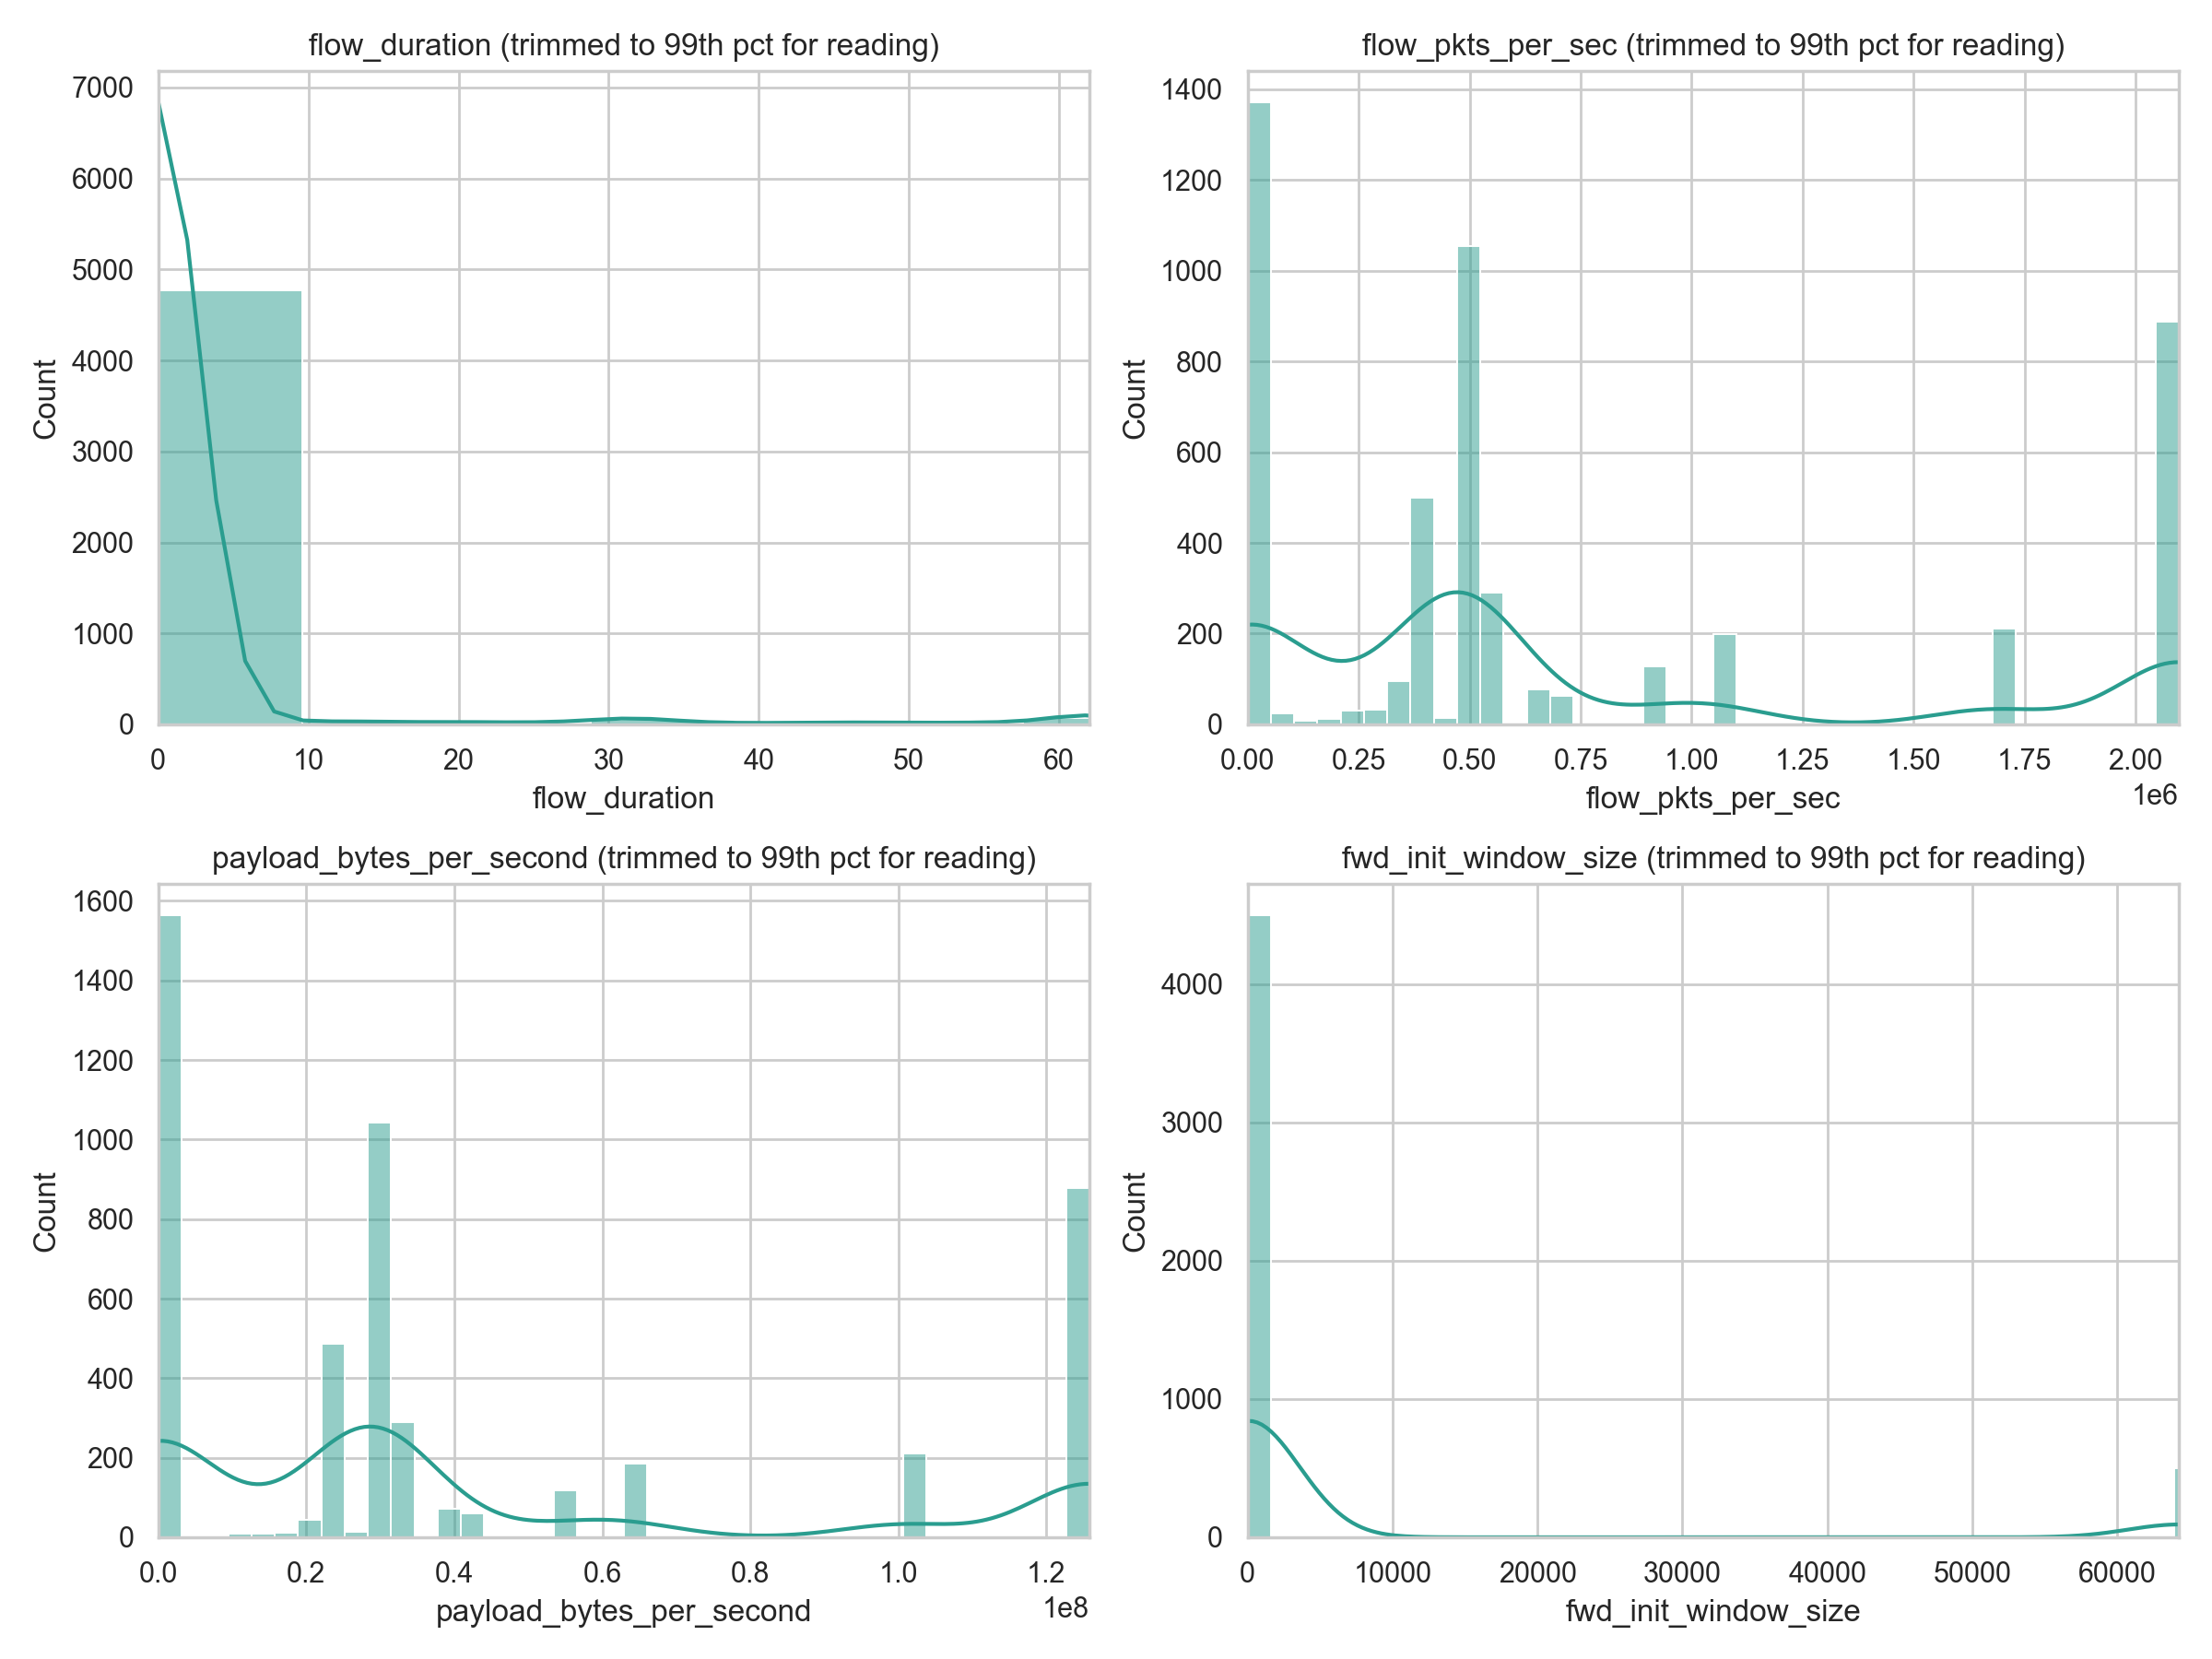

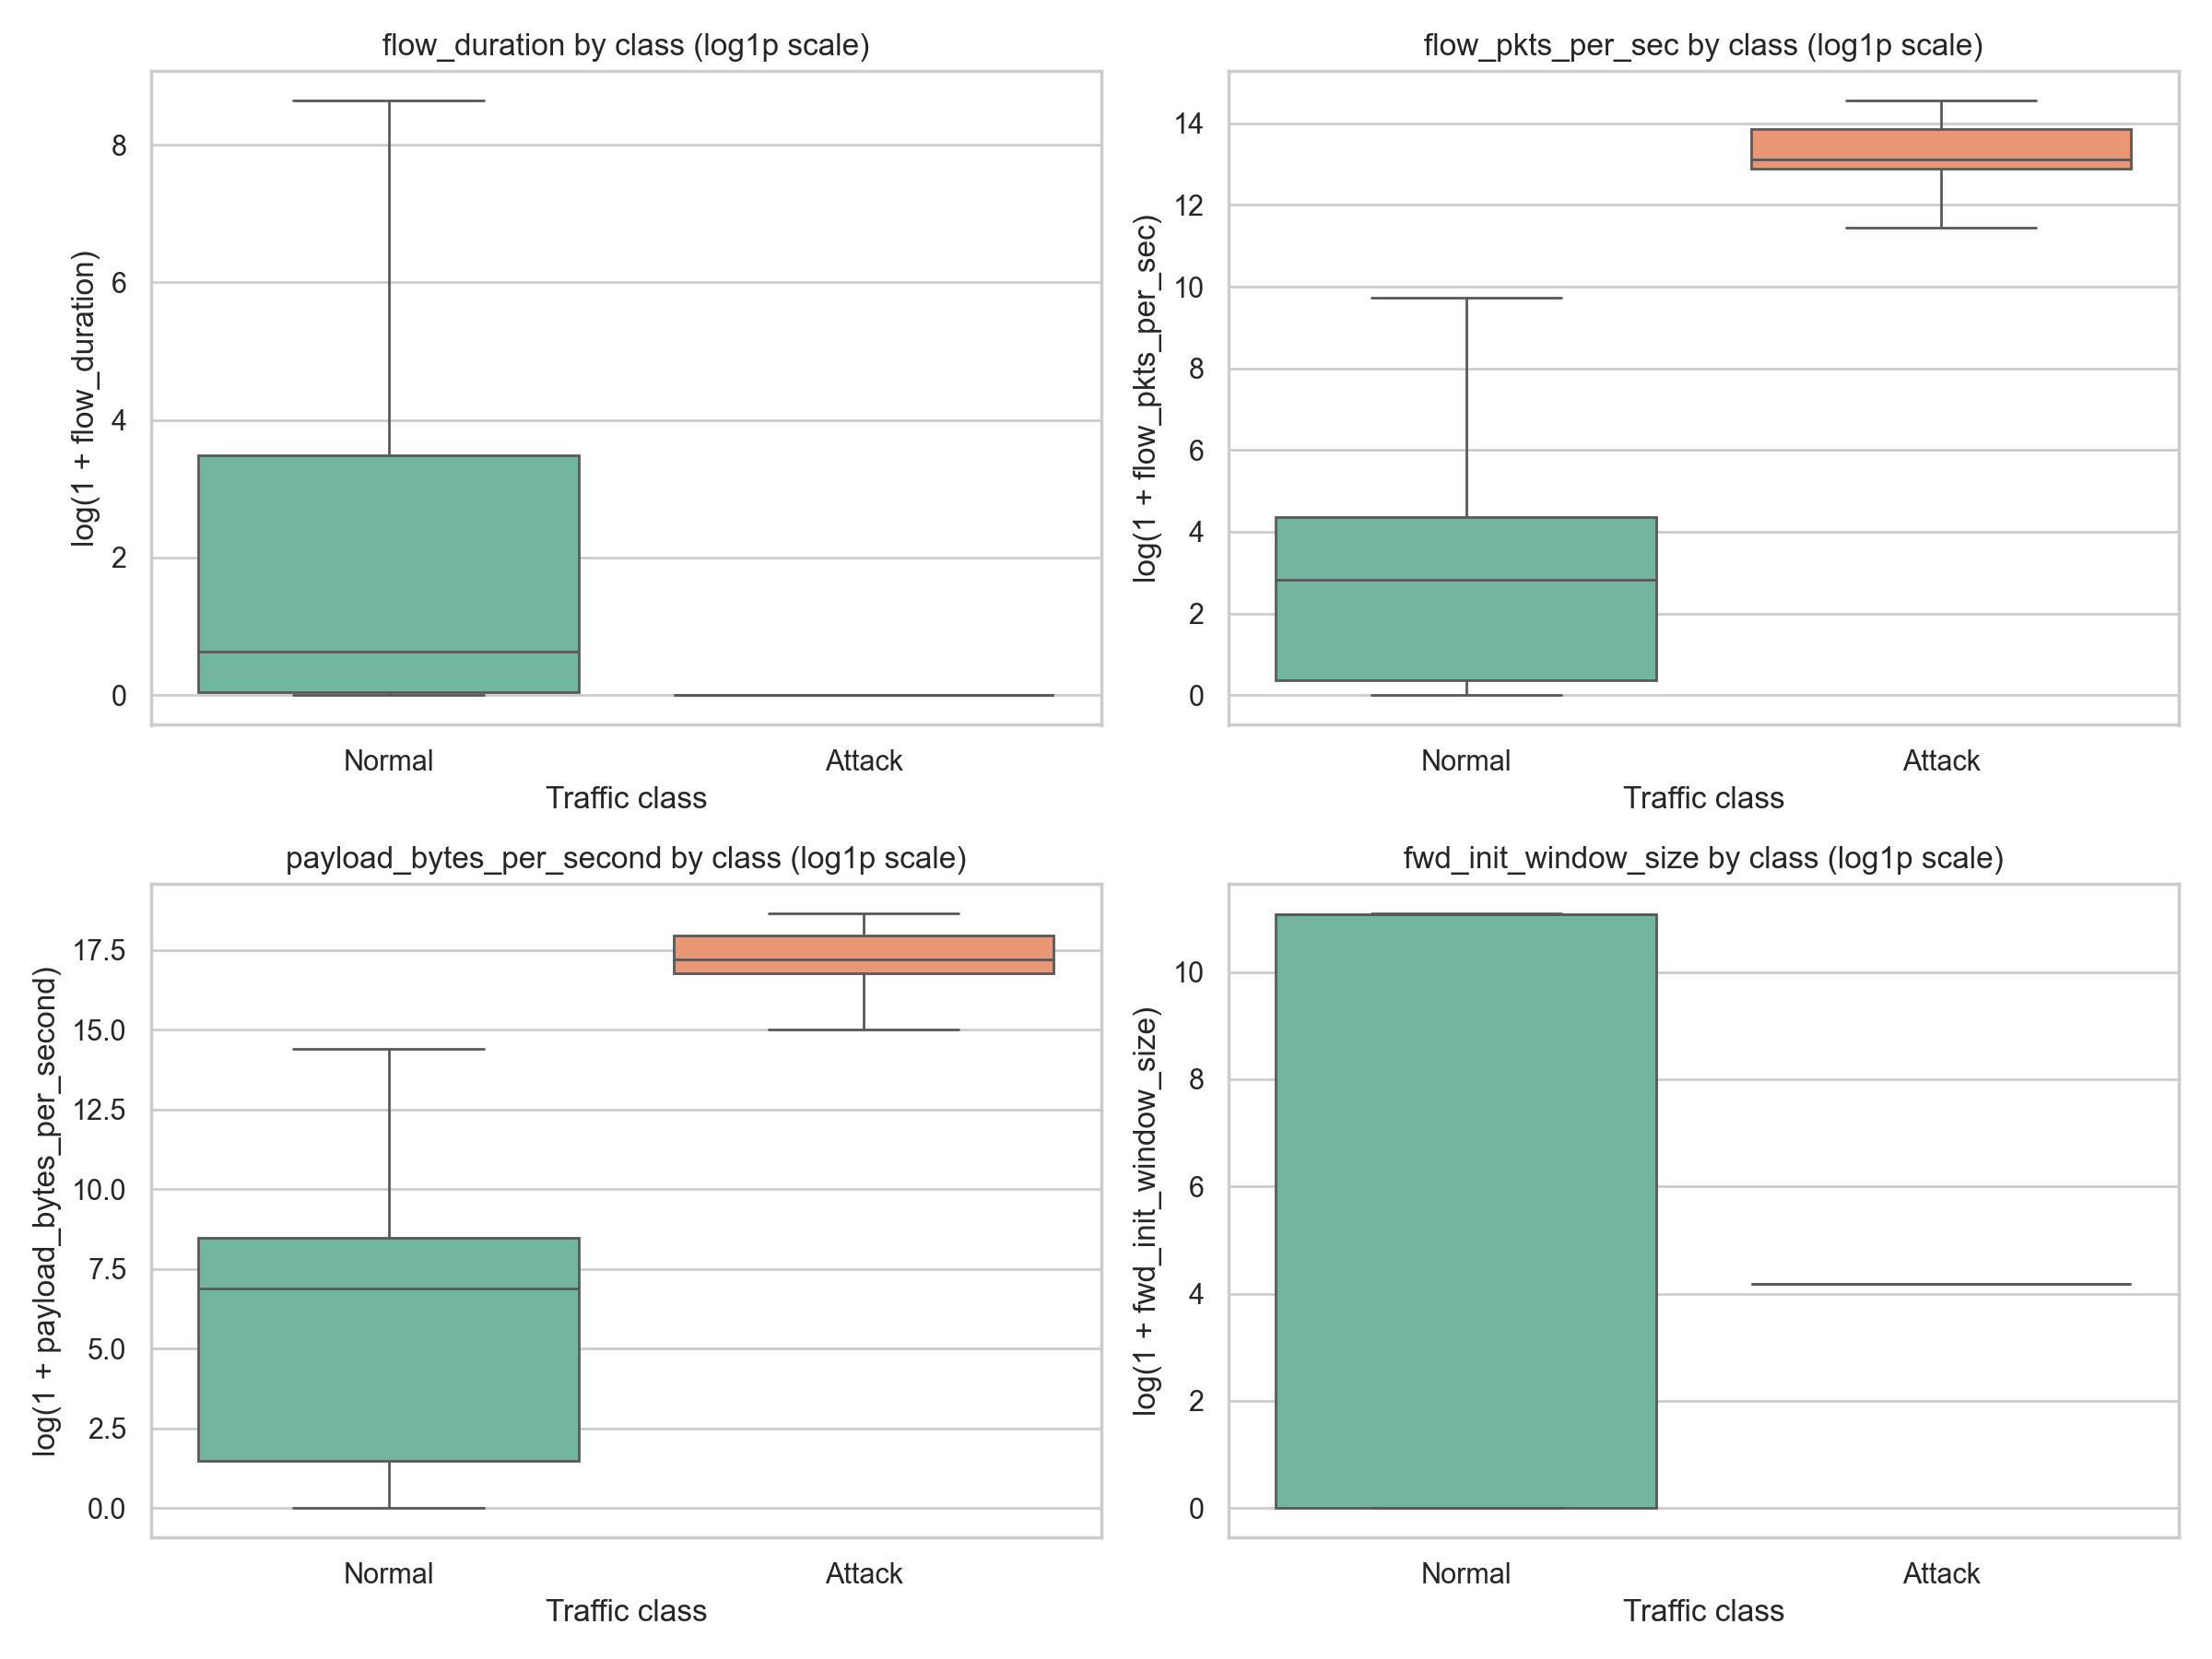

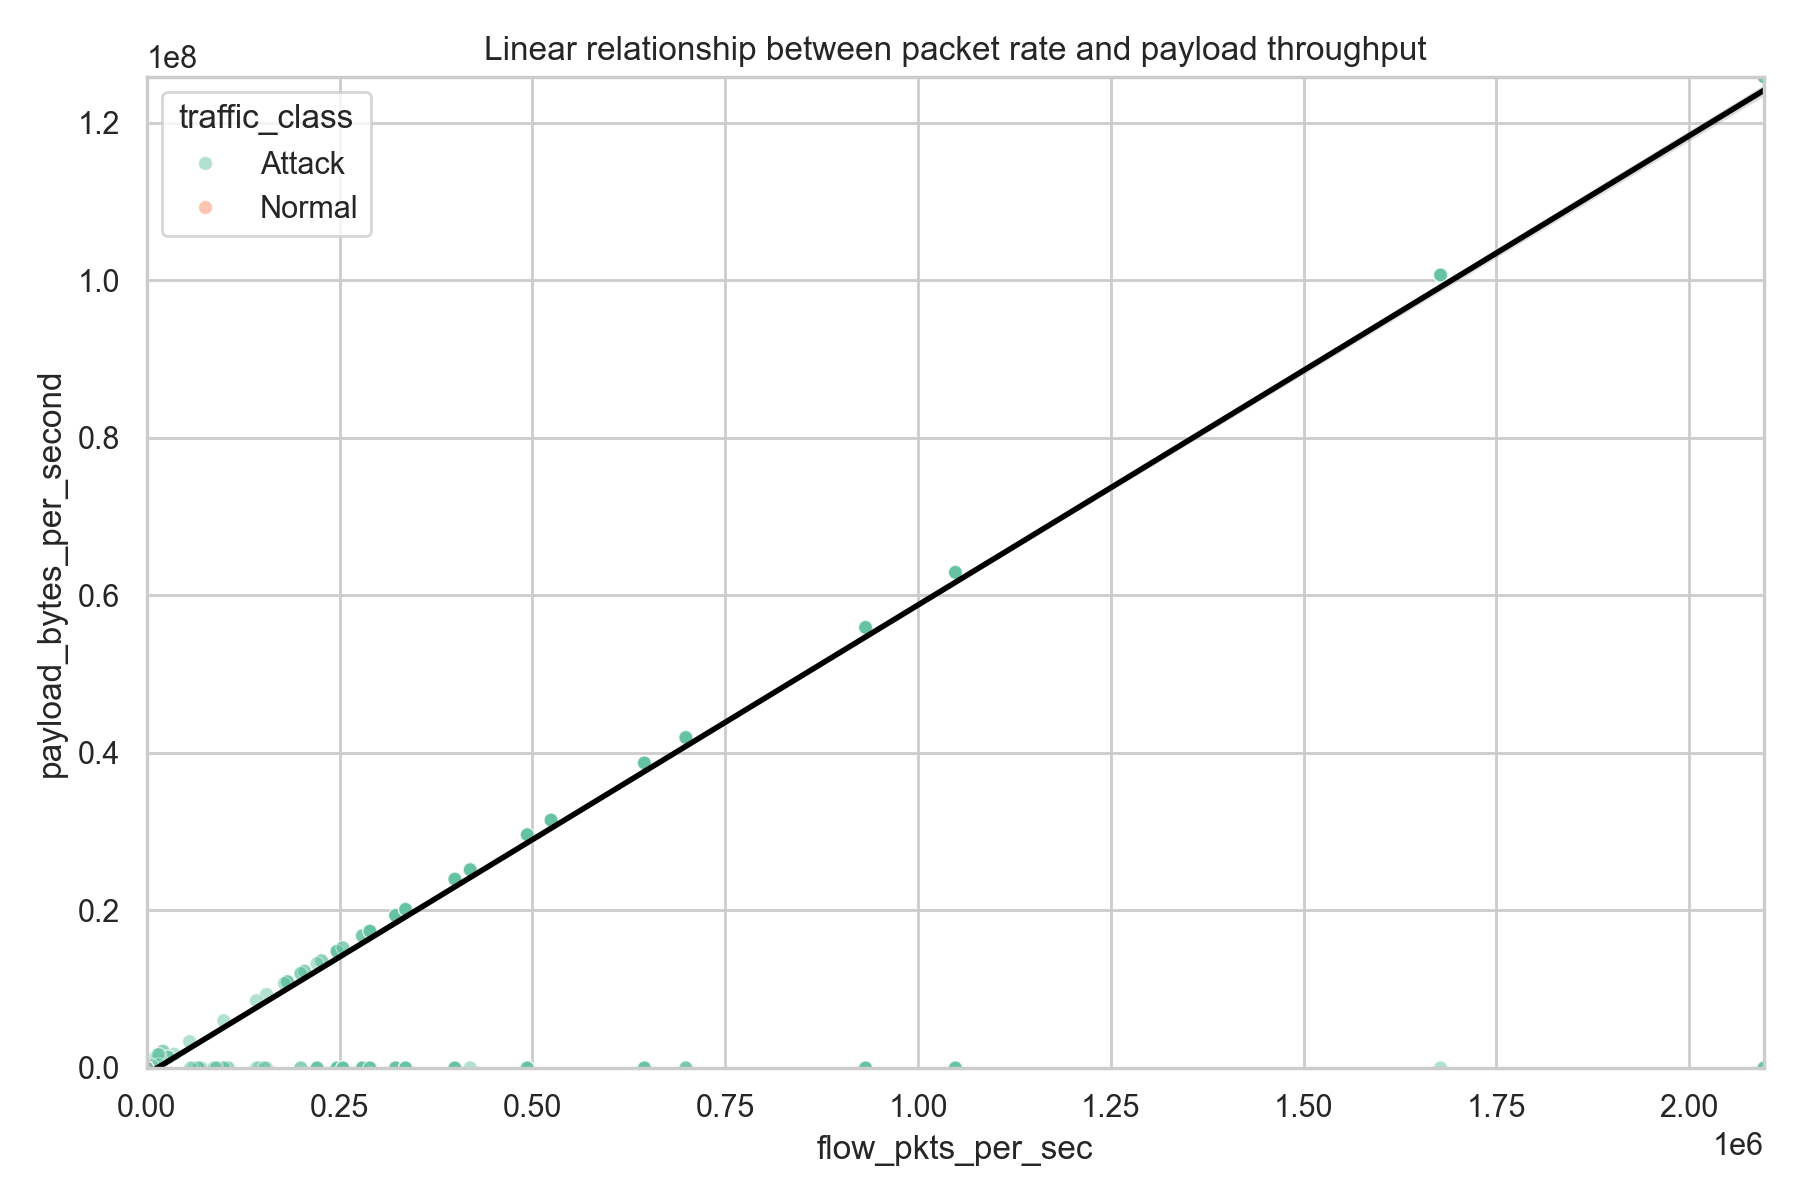

In [5]:
from IPython.display import Image, display

plot_paths = [
    ROOT / 'outputs' / 'plots' / 'class_distribution.png',
    ROOT / 'outputs' / 'plots' / 'histograms_with_kde.png',
    ROOT / 'outputs' / 'plots' / 'boxplots_by_class.png',
    ROOT / 'outputs' / 'plots' / 'scatter_regression.png',
]

for path in plot_paths:
    display(Image(filename=str(path)))

## 4. Выбросы методом IQR

Используем классическое правило:

`[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`

In [6]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in {'id', 'is_attack'}]
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = (df[numeric_cols] < lower) | (df[numeric_cols] > upper)
outliers = pd.DataFrame({
    'feature': numeric_cols,
    'outlier_count': outlier_mask.sum().values,
    'outlier_share': (outlier_mask.sum() / len(df)).values,
    'iqr': iqr.values,
}).sort_values('outlier_count', ascending=False)
outliers[outliers['iqr'] > 0].head(10)

,feature,outlier_count,outlier_share,iqr
55,flow_iat.avg,19180,0.155787,4.053116
54,flow_iat.tot,19180,0.155787,4.053116
53,flow_iat.max,19180,0.155787,4.053116
2,flow_duration,19171,0.155714,0.000004
69,active.max,19165,0.155665,4.053116
71,active.avg,19165,0.155665,4.053116
70,active.tot,19165,0.155665,4.053116
68,active.min,18906,0.153561,4.053116
52,flow_iat.min,15205,0.123500,4.053116
41,flow_pkts_payload.std,5896,0.047889,34.633296


## 5. Гипотеза о равенстве средних

Сравниваем `payload_bytes_per_second` в группах `Attack` и `Normal` критерием Уэлча.

### Почему выбран критерий Уэлча

Нулевая гипотеза:

- `H0`: средние значения `payload_bytes_per_second` в группах `Attack` и `Normal` равны.

Альтернативная гипотеза:

- `H1`: средние различаются.

Я использовал **критерий Уэлча**, потому что:

- группы `Attack` и `Normal` имеют разный размер;
- дисперсии в этих группах различаются;
- критерий Уэлча не требует предположения о равенстве дисперсий.

В коде это задается через:

```python
stats.ttest_ind(attack_values, normal_values, equal_var=False)
```

Формула статистики Уэлча:

```text
t = (x̄1 - x̄2) / sqrt(s1^2 / n1 + s2^2 / n2)
```

где:

- `x̄1, x̄2` — средние двух групп;
- `s1^2, s2^2` — выборочные дисперсии;
- `n1, n2` — размеры групп.

Дополнительно считался размер эффекта `Cohen's d`:

```text
Cohen's d = (x̄1 - x̄2) / pooled_std
```

Это показывает не только факт различия, но и его величину.

In [7]:
attack_values = df.loc[df['is_attack'] == 1, 'payload_bytes_per_second']
normal_values = df.loc[df['is_attack'] == 0, 'payload_bytes_per_second']

t_stat, t_pvalue = stats.ttest_ind(
    attack_values,
    normal_values,
    equal_var=False,
    nan_policy='omit',
)

pooled_std = np.sqrt(
    (
        attack_values.var(ddof=1) * (len(attack_values) - 1)
        + normal_values.var(ddof=1) * (len(normal_values) - 1)
    )
    / (len(attack_values) + len(normal_values) - 2)
)
cohens_d = (attack_values.mean() - normal_values.mean()) / pooled_std

pd.DataFrame([{
    'test': 'Welch t-test',
    'feature': 'payload_bytes_per_second',
    't_stat': t_stat,
    'p_value': t_pvalue,
    'attack_mean': attack_values.mean(),
    'normal_mean': normal_values.mean(),
    'cohens_d': cohens_d,
}]).round(4)

,test,feature,t_stat,p_value,attack_mean,normal_mean,cohens_d
0,Welch t-test,payload_bytes_per_second,337.4742,0.0,4.569507e+07,3656.2041,1.0705


## 6. Гипотеза о нормальности распределения

Проверяем `flow_duration` для нормального трафика тестом Д'Агостино.

### Почему выбран тест Д'Агостино

Нулевая гипотеза:

- `H0`: распределение `flow_duration` для нормального трафика является нормальным.

Альтернативная гипотеза:

- `H1`: распределение не является нормальным.

Я использовал **тест Д'Агостино**, потому что:

- по ТЗ нужно проверить гипотезу о виде распределения;
- тест анализирует **асимметрию** и **эксцесс**;
- он хорошо подходит для больших выборок.

В коде используется:

```python
k2_stat, normality_pvalue = stats.normaltest(normality_sample)
```

Идея теста такая:

- считается, насколько распределение отклоняется от нормального по асимметрии;
- считается, насколько оно отклоняется по эксцессу;
- затем эти отклонения объединяются в статистику `K^2`.

Схематично:

```text
K^2 = Z_skew^2 + Z_kurt^2
```

где:

- `Z_skew` — нормированная мера асимметрии;
- `Z_kurt` — нормированная мера эксцесса.

Если `p-value < 0.05`, гипотеза о нормальности отвергается.

In [8]:
normality_sample = (
    df.loc[df['traffic_class'] == 'Normal', 'flow_duration']
    .sample(n=min(5000, (df['traffic_class'] == 'Normal').sum()), random_state=42)
    .astype(float)
)

k2_stat, normality_pvalue = stats.normaltest(normality_sample)

pd.DataFrame([{
    'test': "D'Agostino K^2 normality test",
    'feature': 'flow_duration',
    'k2_stat': k2_stat,
    'p_value': normality_pvalue,
    'sample_mean': normality_sample.mean(),
}]).round(4)

,test,feature,k2_stat,p_value,sample_mean
0,D'Agostino K^2 normality test,flow_duration,14454.6586,0.0,27.3927


## 7. Линейная регрессия

Строим линейную регрессию между `flow_pkts_per_sec` и `payload_bytes_per_second`.

In [9]:
regression_df = (
    df[['flow_pkts_per_sec', 'payload_bytes_per_second']]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)
result = stats.linregress(regression_df['flow_pkts_per_sec'], regression_df['payload_bytes_per_second'])

pd.DataFrame([{
    'x_feature': 'flow_pkts_per_sec',
    'y_feature': 'payload_bytes_per_second',
    'slope': result.slope,
    'intercept': result.intercept,
    'r_value': result.rvalue,
    'r_squared': result.rvalue ** 2,
    'p_value': result.pvalue,
}]).round(4)

,x_feature,y_feature,slope,intercept,r_value,r_squared,p_value
0,flow_pkts_per_sec,payload_bytes_per_second,59.5395,-836665.1888,0.9843,0.9688,0.0


## 8. Короткий вывод

Атакующий трафик статистически сильно отличается от нормального и связан с более высокой сетевой нагрузкой. Это видно по интенсивности трафика, полезной нагрузке и временным характеристикам потока. Проверка гипотез подтвердила, что различия между `Attack` и `Normal` не случайны.